# 00 · Setup and smoke test

Checks that the whole stack works on this machine, end to end:

1. install and imports
2. render the four target environments
3. get a TwoRoom dataset
4. load the released LeWM checkpoint
5. run one small planning evaluation (CEM + MPC)

Runs on Colab (GPU) and locally (CUDA, Apple MPS or CPU). On a machine with less than 20 GB of free disk it
collects a tiny TwoRoom dataset itself instead of downloading the released 12.8 GB one, so the numbers are
only a smoke test there.

## 1. Paths and environment variables

In [1]:
import os
import shutil
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    ROOT = Path("/content")
else:
    ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

# must be set before importing stable_worldmodel / mujoco
os.environ["STABLEWM_HOME"] = str(ROOT / "stablewm")      # datasets/ and checkpoints/ live here
os.environ.setdefault("WANDB_MODE", "disabled")
if sys.platform == "linux":
    os.environ.setdefault("MUJOCO_GL", "egl")             # headless rendering; macOS uses its default

HOME = Path(os.environ["STABLEWM_HOME"])
(HOME / "datasets").mkdir(parents=True, exist_ok=True)
print("root:", ROOT)
print("STABLEWM_HOME:", HOME)
print(f"free disk: {shutil.disk_usage(HOME).free / 1e9:.0f} GB")

root: /content
STABLEWM_HOME: /content/stablewm
free disk: 75 GB


## 2. Install (Colab only)

Locally the project venv already has these. The pins matter:

- `mujoco<3.15`: `dm_control` 1.0.47 crashes on mujoco 3.15 (Reacher).
- `transformers<5`: the released checkpoints use the 4.x ViT layer names.
- `hdf5plugin`: without it the HDF5 dataset reader is silently missing.

`labmaze` (a dependency of `dm_control`) has no wheels for Python 3.13 and newer and fails to build without
bazel. It is only used for maze arenas we never touch, so on those Python versions an empty stand-in package
is installed first to satisfy the requirement.

The install uses `uv` because its resolver picks the same versions as the tested local setup.
If Colab asks to restart the runtime after this cell, restart and run from the top again.

In [3]:
PACKAGES = [
    "stable-worldmodel[train,env]==0.1.1",
    "hdf5plugin",
    "mujoco>=3.14,<3.15",
    "transformers>=4.50,<5",
    "datasets>=3",
    "huggingface-hub<1",
]

if IN_COLAB:
    import subprocess

    def pip(*args):
        cmd = [sys.executable, "-m", "uv", "pip", "install", "--system", *args]
        result = subprocess.run(cmd, capture_output=True, text=True)
        if result.returncode != 0:
            print((result.stdout + result.stderr)[-6000:])      # uv's own error message
            raise RuntimeError("install failed, see the output above")

    # Install system dependency swig required to compile box2d-py
    print("Installing system dependencies (swig)... ")
    subprocess.run(["apt-get", "update", "-y"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    subprocess.run(["apt-get", "install", "-y", "swig"], check=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "uv"], check=True)

    if sys.version_info >= (3, 13):
        stub = Path("/content/labmaze_stub")
        (stub / "labmaze").mkdir(parents=True, exist_ok=True)
        (stub / "labmaze" / "__init__.py").write_text("# empty stand-in, see notebook section 2\n")
        (stub / "pyproject.toml").write_text(
            "[build-system]\nrequires = [\"setuptools\"]\nbuild-backend = \"setuptools.build_meta\"\n"
            "[project]\nname = \"labmaze\"\nversion = \"1.0.6\"\n"
        )
        pip(str(stub))

    pip(*PACKAGES)
    print("installed on python", sys.version.split()[0])

Installing system dependencies (swig)... 
installed on python 3.13.15


In [4]:
import sys

print("Your current Python version is:", sys.version)

Your current Python version is: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]


## 3. Imports and device

In [5]:
import platform
import time
import warnings
from importlib.metadata import version

import numpy as np
import torch

warnings.filterwarnings("ignore")
import stable_pretraining as spt
import stable_worldmodel as swm

DEVICE = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
GPU = torch.cuda.get_device_name(0) if DEVICE == "cuda" else DEVICE

print("python", platform.python_version(), "| torch", torch.__version__, "| device", GPU)
for pkg in ["stable-worldmodel", "stable-pretraining", "transformers", "mujoco", "dm-control"]:
    print(f"{pkg:20s} {version(pkg)}")
assert hasattr(swm.data, "HDF5Dataset"), "HDF5 reader missing: pip install hdf5plugin"

20:37:45 | INFO  | __init__.py | NumExpr defaulting to 2 threads.
python 3.13.15 | torch 2.11.0+cu130 | device Tesla T4
stable-worldmodel    0.1.1
stable-pretraining   0.1.8
transformers         4.57.6
mujoco               3.14.0
dm-control           1.0.47


## 4. Render the four target environments

Five frames each under random actions. Every env should return 224 x 224 RGB frames.

swm/PushT-v1: frame (224, 224, 3), action dim (2,)
swm/TwoRoom-v1: frame (224, 224, 3), action dim (2,)
20:38:05 | INFO  | __init__.py | No OpenGL_accelerate module loaded: No module named 'OpenGL_accelerate'
20:38:06 | INFO  | __init__.py | MUJOCO_GL=egl, attempting to import specified OpenGL backend.
20:38:06 | INFO  | __init__.py | MuJoCo library version is: 3.14.0
swm/OGBCube-v0: frame (224, 224, 3), action dim (5,)
swm/ReacherDMControl-v0: frame (224, 224, 3), action dim (2,)


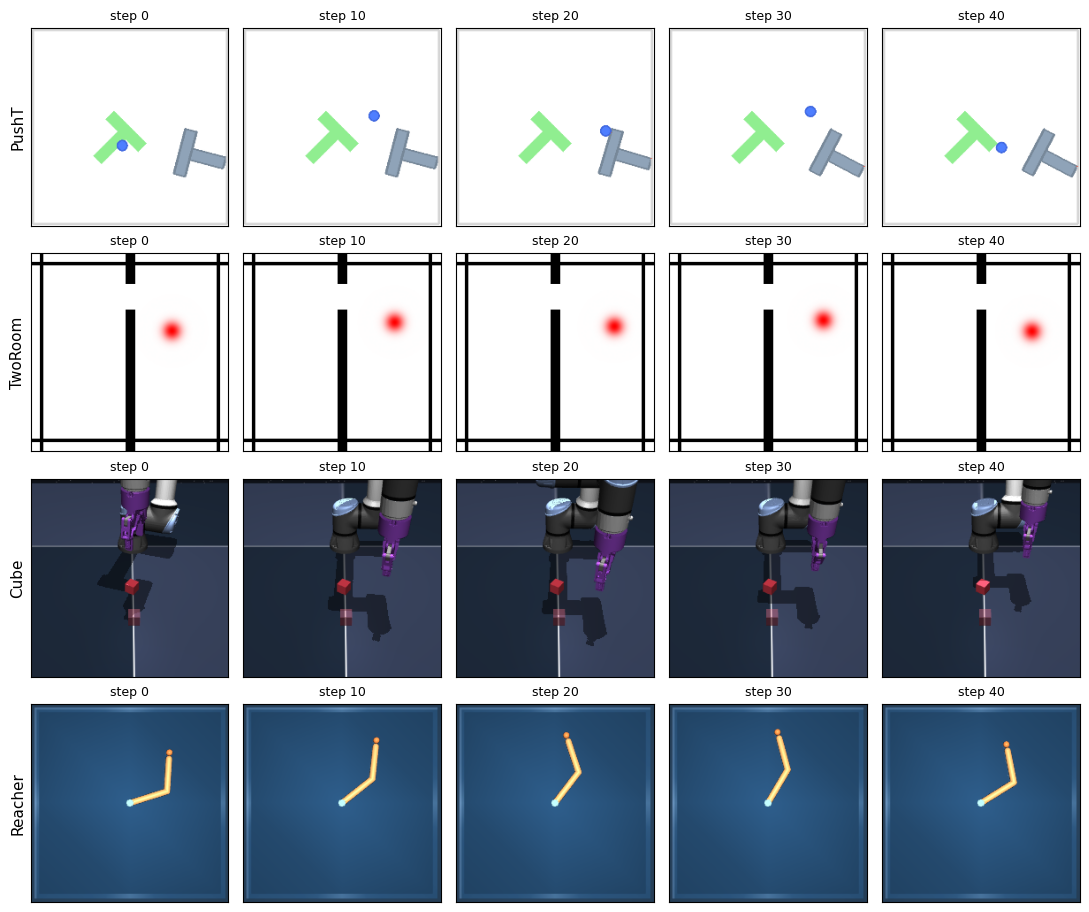

In [6]:
import gymnasium as gym
import matplotlib.pyplot as plt

ENVS = {
    "PushT": "swm/PushT-v1",
    "TwoRoom": "swm/TwoRoom-v1",
    "Cube": "swm/OGBCube-v0",
    "Reacher": "swm/ReacherDMControl-v0",
}
N_FRAMES, STEPS_BETWEEN = 5, 10


def random_rollout(env_id, seed=0):
    env = gym.make(env_id, render_mode="rgb_array")
    env.reset(seed=seed)
    env.action_space.seed(seed)
    frames = [env.render()]
    for _ in range(N_FRAMES - 1):
        for _ in range(STEPS_BETWEEN):
            _, _, terminated, truncated, _ = env.step(env.action_space.sample())
            if terminated or truncated:
                env.reset()
        frames.append(env.render())
    print(f"{env_id}: frame {frames[0].shape}, action dim {env.action_space.shape}")
    env.close()
    return frames


fig, axes = plt.subplots(len(ENVS), N_FRAMES, figsize=(2.2 * N_FRAMES, 2.3 * len(ENVS)))
for row, (name, env_id) in zip(axes, ENVS.items()):
    for t, (ax, frame) in enumerate(zip(row, random_rollout(env_id))):
        ax.imshow(frame)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(f"step {t * STEPS_BETWEEN}", fontsize=9)
    row[0].set_ylabel(name, fontsize=11)
fig.tight_layout()
plt.show()

## 5. TwoRoom dataset

The released dataset is a 3.4 GB archive that unpacks to a 12.8 GB `tworoom.h5`. The archive is streamed
straight into the extractor, so it never sits on disk next to the extracted file.

With less than 20 GB free, the cell instead collects a few expert episodes into `tworoom_local.h5`
(about 250 MB). That is enough to test the planning path, not to report numbers.

In [7]:
import tarfile
import urllib.request

import zstandard
from tqdm.auto import tqdm

TWOROOM_URL = "https://huggingface.co/datasets/quentinll/lewm-tworooms/resolve/main/tworoom.tar.zst"
MIN_FREE_GB = 20
LOCAL_EPISODES = 20


def download_and_extract(url, dest_dir):
    """Stream a .tar.zst from `url` and extract it into `dest_dir`."""
    with urllib.request.urlopen(url) as resp:
        total = int(resp.headers.get("Content-Length", 0)) or None
        with tqdm.wrapattr(resp, "read", total=total, desc=Path(url).name) as raw:
            with zstandard.ZstdDecompressor().stream_reader(raw) as zr:
                with tarfile.open(fileobj=zr, mode="r|") as tar:
                    tar.extractall(dest_dir)


def collect_local_tworoom(path, episodes):
    from stable_worldmodel.envs.two_room import ExpertPolicy

    world = swm.World("swm/TwoRoom-v1", num_envs=4, image_shape=(224, 224),
                      max_episode_steps=100, render_mode="rgb_array")
    world.set_policy(ExpertPolicy(action_noise=2.0, action_repeat_prob=0.05))
    world.collect(path, episodes=episodes, seed=0, format="hdf5")
    world.close()


free_gb = shutil.disk_usage(HOME).free / 1e9
if (HOME / "datasets" / "tworoom.h5").exists():
    DATASET = "tworoom"
elif free_gb >= MIN_FREE_GB:
    download_and_extract(TWOROOM_URL, HOME / "datasets")
    DATASET = "tworoom"
else:
    DATASET = "tworoom_local"
    if not (HOME / "datasets" / "tworoom_local.h5").exists():
        print(f"only {free_gb:.0f} GB free: collecting {LOCAL_EPISODES} local episodes instead")
        collect_local_tworoom(HOME / "datasets" / "tworoom_local.h5", LOCAL_EPISODES)

dataset = swm.data.HDF5Dataset(DATASET, keys_to_cache=["action", "proprio"])
lengths, offsets = np.asarray(dataset.lengths), np.asarray(dataset.offsets)
print(f"dataset: {DATASET} | {len(lengths)} episodes | {lengths.sum()} steps | columns: {dataset.column_names}")

tworoom.tar.zst:   0%|          | 0/3425937909 [00:00<?, ?it/s]

20:39:39 | INFO  | __init__.py | Cached 'action' from '/content/stablewm/datasets/tworoom.h5'
20:39:40 | INFO  | __init__.py | Cached 'proprio' from '/content/stablewm/datasets/tworoom.h5'
dataset: tworoom | 10000 episodes | 920809 steps | columns: ['action', 'distance_to_target', 'ep_idx', 'id', 'observation', 'pixels', 'pos_agent', 'pos_target', 'proprio', 'render_time', 'reward', 'step_idx', 'terminated', 'truncated']


## 6. Load the released LeWM checkpoint

`load_pretrained` fetches `weights.pt` and `config.json` from the Hugging Face repo (70 MB, MIT license) into
`$STABLEWM_HOME/checkpoints/` and builds the model from the config.

In [8]:
model = swm.wm.utils.load_pretrained("quentinll/lewm-tworooms").to(DEVICE).eval()
model.requires_grad_(False)
print(type(model).__name__, f"| {sum(p.numel() for p in model.parameters()) / 1e6:.1f} M parameters | on {DEVICE}")

20:39:53 | INFO  | utils.py    | Downloading quentinll/lewm-tworooms from HuggingFace...
20:39:53 | INFO  | utils.py    | Fetching https://huggingface.co/quentinll/lewm-tworooms/resolve/main/config.json


config.json: 100%|██████████| 1.31k/1.31k [00:00<00:00, 2.98MB/s]

20:39:53 | INFO  | utils.py    | Fetching https://huggingface.co/quentinll/lewm-tworooms/resolve/main/weights.pt



weights.pt: 100%|██████████| 72.3M/72.3M [00:01<00:00, 68.7MB/s]

20:39:54 | INFO  | utils.py    | Loading checkpoint from folder /content/stablewm/checkpoints/models--quentinll--lewm-tworooms...


20:40:13 | INFO  | __init__.py | TensorFlow version 2.21.0 available.
20:40:13 | INFO  | __init__.py | JAX version 0.11.1 available.
20:40:15 | INFO  | atomic_chec~| [atomic_save] installed crash-safe checkpoint plugin (write to sibling .tmp + fsync + atomic rename)
20:40:15 | INFO  | utils.py    | Created ViT-tiny from scratch with config: {'hidden_size': 192, 'num_hidden_layers': 12, 'num_attention_heads': 3, 'intermediate_size': 768, 'image_size': 224, 'patch_size': 14}
LeWM | 18.0 M parameters | on cuda


## 7. One planning evaluation

Same protocol as LeWM's `eval.py`: start states and goals come from dataset episodes (goal = the state
25 steps later), CEM with 300 samples, 30 iterations and 30 elites, horizon 5 action blocks of 5 env steps,
whole plan executed before replanning, budget 50 env steps.

50 episodes on a CUDA GPU, 4 otherwise.

In [9]:
from sklearn import preprocessing
from torchvision.transforms import v2 as transforms

N_EVAL = 50 if DEVICE == "cuda" else 4
GOAL_OFFSET, EVAL_BUDGET, SEED = 25, 50, 42

# --- start/goal queries: draw N_EVAL (episode, start step) pairs that leave room for the goal
row_episode = np.repeat(np.arange(len(lengths)), lengths)
row_step = np.arange(lengths.sum()) - np.repeat(offsets, lengths)
valid_rows = np.nonzero(row_step <= np.repeat(lengths, lengths) - GOAL_OFFSET - 1)[0]
rng = np.random.default_rng(SEED)
rows = np.sort(valid_rows[rng.choice(len(valid_rows) - 1, size=N_EVAL, replace=False)])
episodes_idx, start_steps = row_episode[rows].tolist(), row_step[rows].tolist()
print("episodes:", episodes_idx)
print("start steps:", start_steps)

# --- preprocessing: ImageNet-normalised pixels, z-scored actions and proprio (stats from the dataset)
def img_transform():
    return transforms.Compose([
        transforms.ToImage(),
        transforms.ToDtype(torch.float32, scale=True),
        transforms.Normalize(**spt.data.dataset_stats.ImageNet),
        transforms.Resize(size=224),
    ])

process = {}
for col in ["action", "proprio"]:
    data = dataset.get_col_data(col)
    process[col] = preprocessing.StandardScaler().fit(data[~np.isnan(data).any(axis=1)])
    if col != "action":
        process[f"goal_{col}"] = process[col]

# --- world, solver, policy
world = swm.World("swm/TwoRoom-v1", num_envs=N_EVAL, image_shape=(224, 224),
                  max_episode_steps=2 * EVAL_BUDGET)
solver = swm.solver.CEMSolver(model=model, num_samples=300, n_steps=30, topk=30,
                              device=DEVICE, seed=SEED)
policy = swm.policy.WorldModelPolicy(
    solver=solver,
    config=swm.PlanConfig(horizon=5, receding_horizon=5, action_block=5),
    process=process,
    transform={"pixels": img_transform(), "goal": img_transform()},
)
world.set_policy(policy)

# how to put each env into the dataset's start state and goal
callables = [
    {"method": "_set_state", "args": {"state": {"value": "proprio"}}},
    {"method": "_set_goal_state", "args": {"goal_state": {"value": "goal_proprio"}}},
]

VIDEO_DIR = HOME / "smoke_videos"
t0 = time.time()
metrics = world.evaluate(
    dataset=dataset,
    episodes_idx=episodes_idx,
    start_steps=start_steps,
    goal_offset=GOAL_OFFSET,
    eval_budget=EVAL_BUDGET,
    callables=callables,
    video=VIDEO_DIR,
)
wall = time.time() - t0
world.close()

print(f"\nsuccess rate: {metrics['success_rate']:.0f}% over {N_EVAL} episodes "
      f"| wall time {wall:.0f} s on {GPU} | dataset {DATASET}")

episodes: [644, 687, 872, 905, 933, 953, 1287, 1661, 1832, 2019, 2280, 2773, 3558, 3719, 4032, 4339, 4398, 4445, 4467, 4515, 4516, 5014, 5141, 5272, 5459, 5552, 6320, 6446, 6552, 6791, 6988, 7021, 7189, 7370, 7597, 7627, 7751, 7797, 7826, 7873, 8241, 8289, 8411, 8598, 8601, 8895, 8949, 9277, 9711, 9757]
start steps: [42, 68, 25, 16, 20, 17, 72, 21, 10, 36, 50, 13, 57, 39, 0, 7, 52, 6, 38, 21, 0, 72, 7, 33, 55, 36, 28, 26, 41, 37, 59, 44, 16, 22, 55, 48, 27, 32, 66, 32, 30, 18, 21, 31, 39, 31, 49, 75, 8, 70]
CEM solve time: 100.1082 seconds
CEM solve time: 16.6157 seconds

success rate: 86% over 50 episodes | wall time 151 s on Tesla T4 | dataset tworoom


## 8. Watch one episode

Each video shows the agent's rollout next to the dataset trajectory and the goal image.

In [10]:
from IPython.display import Video

videos = sorted(VIDEO_DIR.glob("*.mp4"))
print(len(videos), "videos in", VIDEO_DIR)
Video(str(videos[0]), embed=True, width=480)

50 videos in /content/stablewm/smoke_videos


## What this does not cover yet

- The DINO-WM baseline checkpoints (Google Drive only) and whether they load on this package version.
- PushT, Cube and Reacher planning.
- Timing: the wall time above includes environment stepping and a warm-up solve.